[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/KalininGroup/camm_hackathon/blob/k4my4r/docs/day_5_11212025/2025_Ferrosim_CAMM_hackaton.ipynb)


# **FerroSim: Kinetic Lattice Ferroelectric Model**

**Author: Rama Vasudevan**

This simulator evolves a ferroelectric polarization field using a time-dependent Ginzburg–Landau (TDGL) model on a 2D lattice. Each site carries a polarization order parameter:

- **Uniaxial:** scalar $p_{ij}$
- **Squareelectric:** two uncoupled components $(p_{x,ij},p_{y,ij})$
- **Tetragonal / Rhombohedral:** coupled vector $(p_{x,ij},p_{y,ij})$

The total free energy is:
$$
F = F_{\text{Landau}} + F_{\text{coupl}} + F_{\text{field}}
$$

### **1. Landau Free Energy (local double-well / multi-well potential)**

- **Uniaxial / Squareelectric:**
  $$
  F_L = \frac{\alpha_1}{2}p^2 + \frac{\alpha_2}{4}p^4
  $$
- **Tetragonal / Rhombohedral:**
  $$
  F_L = \alpha_1 (p_x^2+p_y^2)
       + \alpha_2 (p_x^4+p_y^4)
       + \alpha_3 p_x^2 p_y^2
  $$

### **2. Couping Energy**

$$
F_{\text{coupl}} = K \sum_{k,l} (p_{ij} - p_{i+k,j+l})^2
$$


### **3. Electric Field Terms**

Local field:
$$
E_{\text{loc}} = E_{\text{ext}} + E_{\text{dep}} + E_d(i,j)
$$

Depolarization field:
$$
E_{\text{dep}} = -\alpha_{\text{dep}} \langle P \rangle
\qquad
\langle P \rangle = \frac{1}{N^2}\sum_{ij} p_{ij}
$$

External field $E_{\text{ext}}(t)$ can be an arbitrary waveform.

Defect field $E_d(i,j)$ introduces random-field.

### **4. TDGL Dynamics**

Evolution follows:
$$
\frac{dp_{ij}}{dt} = -\gamma \frac{\partial F}{\partial p_{ij}}
$$

Updated explicitly:
$$
p_{ij}(t+\Delta t) = p_{ij}(t) + \Delta t\,\frac{dp_{ij}}{dt}
$$

$\gamma$ is the mobility (domain-wall damping).  
$\Delta t$ is the numerical time step.

### **5. Model Parameters**

- **Landau coefficients:** $\alpha_1, \alpha_2, \alpha_3$
- **Coupling:** $K$
- **Depolarizing coef.:** $\alpha_{\text{dep}}$
- **External field:** $E_{\text{ext}}(t)$
- **Defect field:** $E_d(i,j)$
- **Mobility:** $\gamma$
- **Time step:** $\Delta t$

### **Modes Summary**

- **Uniaxial:** scalar double-well potential.
- **Squareelectric:** two independent double wells in $x$ and $y$.
- **Tetragonal:** coupled components; minima along axes.
- **Rhombohedral:** coupled components; minima along diagonal directions.

This toy model captures ferroelectric switching, domain formation, domain wall motion, defect pinning, and polarization dynamics under applied fields.


**Default coef.** **$\alpha_1$ $\alpha_2$ $\alpha_3$**

*Uniaxial:* -1.85,	1.25, N/A

*Squareelectric:* -1.85,	1.25, N/A

*Tetragonal:* -1.6	12.2	40.0

*Rhombohedral:* -10.6	10.2	-10.0

**NOTE: The coefficients for the rhomohedral case don't appear to be very good. Need to adjust them.**





---






**Github**: https://github.com/ramav87/FerroSim/tree/rama-dev (branch: rama-dev)

In [ ]:
!pip install -e git+https://github.com/ramav87/FerroSim.git@rama-dev#egg=FerroSim

Obtaining FerroSim from git+https://github.com/ramav87/FerroSim.git@rama-dev#egg=FerroSim
  Cloning https://github.com/ramav87/FerroSim.git (to revision rama-dev) to ./src/ferrosim
  Running command git clone --filter=blob:none --quiet https://github.com/ramav87/FerroSim.git /content/src/ferrosim
  Running command git checkout -b rama-dev --track origin/rama-dev
  Switched to a new branch 'rama-dev'
  Branch 'rama-dev' set up to track remote branch 'rama-dev' from 'origin'.
  Resolved https://github.com/ramav87/FerroSim.git to commit 83b79be078001e93d4d10fcab403ba2f8d688a27
  Preparing metadata (setup.py) ... done
  Running setup.py develop for FerroSim




> **Session must be restarted after ferrosim lib uploading**



In [ ]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import gridspec

import h5py
import math

from typing import Dict
from itertools import product

from ferrosim import Ferro2DSim

## Uniaxial switching

---Performing simulation---


100%|██████████| 498/498 [00:08<00:00, 59.67it/s] 


---Performing simulation---


100%|██████████| 498/498 [00:03<00:00, 156.69it/s]


---Performing simulation---


100%|██████████| 498/498 [00:03<00:00, 144.49it/s]


---Performing simulation---


100%|██████████| 498/498 [00:03<00:00, 131.29it/s]


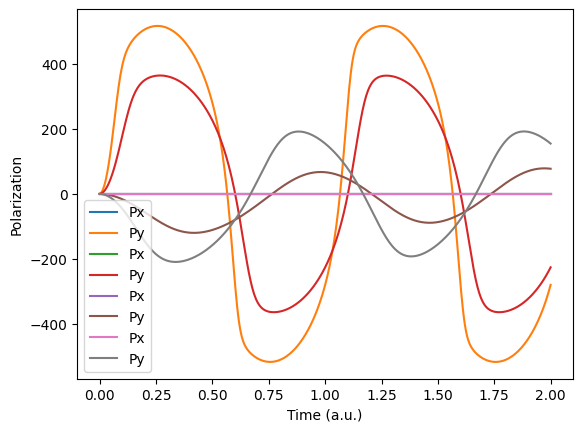

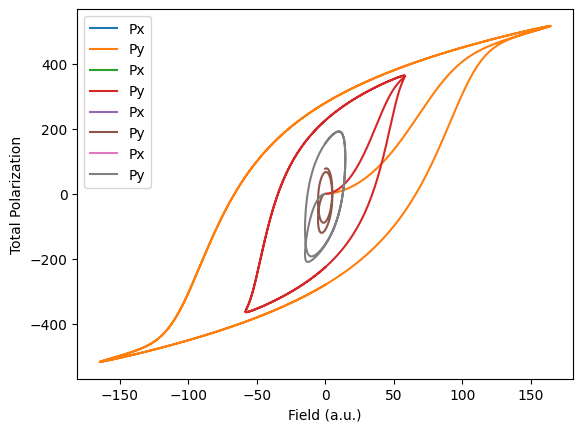

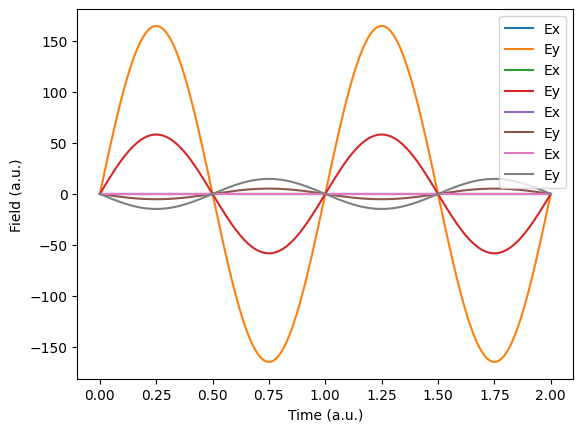

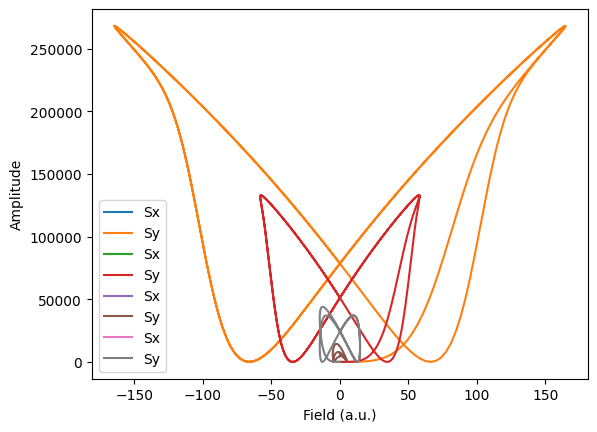

In [ ]:
Pmats = []
for temp in [300, 350, 410, 420]:
  time_vec = np.linspace(0,2,500)

  #Let's now make a somewhat complicated electric field
  Evec_x = 0*np.ones(len(time_vec))
  Evec_y = 190*np.sin(2*np.pi*time_vec)
  applied_field = np.vstack((Evec_x, Evec_y)).T

  landau_parms = {'alpha1': 1.85/100 , 'alpha2':1.25 } #alpha1 is technically the temperature independent term, it gets multiplied by T diff.

  init_pmat = np.random.uniform(low = -0.2, high = 0.2, size = (10,10))*1.0E-6
  init_pmat_full = np.zeros(shape=(10,10,2))
  init_pmat_full[:,:,1] = init_pmat


  sim = Ferro2DSim(mode = 'uniaxial',
                   k = 1.0,
                   temp = temp,
                   time_vec = time_vec,
                   appliedE = applied_field,
                   initial_p = init_pmat_full,
                   landau_parms = landau_parms,
                   )
  sim.runSim()

  sim.plot_summary()
  #sim.plot_quiver()
  Pmats.append(sim.getPmat())
  del sim

(array([-600., -400., -200.,    0.,  200.,  400.,  600.]),
 [Text(0, -600.0, '−600'),
  Text(0, -400.0, '−400'),
  Text(0, -200.0, '−200'),
  Text(0, 0.0, '0'),
  Text(0, 200.0, '200'),
  Text(0, 400.0, '400'),
  Text(0, 600.0, '600')])

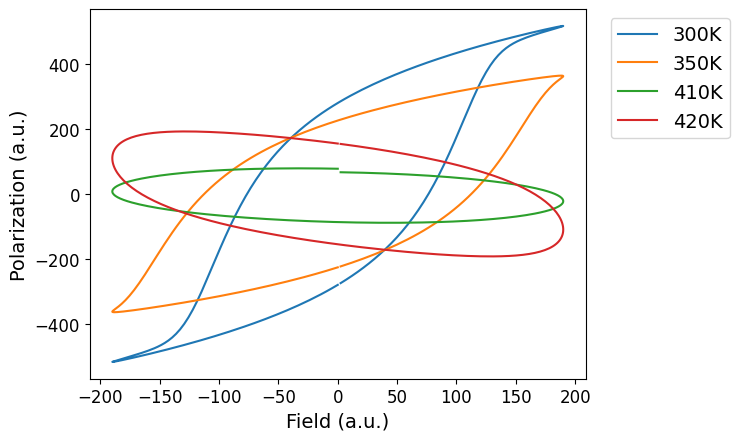

In [ ]:
plt.figure()
labels = ['300K', '350K', '410K', '420K']
for ind in range(4):
  fe_loop = Pmats[ind][1,:,:,:].sum(axis=((-1,-2)))
  plt.plot(applied_field[250:,1], fe_loop[250:], label = labels[ind])
plt.legend(loc = [1.05, 0.65], fontsize = 14)

plt.xlabel('Field (a.u.)', fontsize = 14)
plt.ylabel('Polarization (a.u.)', fontsize = 14)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)

## Custom field: tetragonal

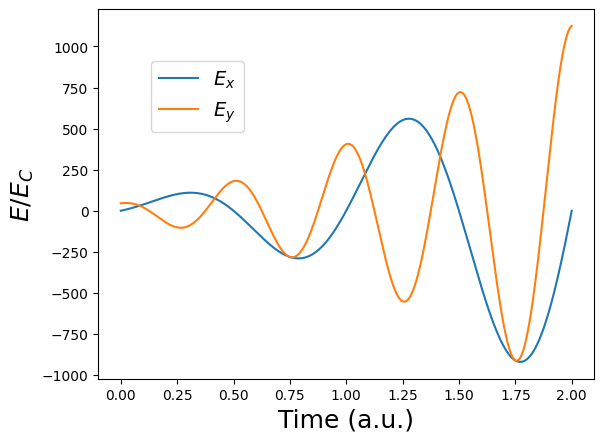

In [ ]:
time_vec = np.linspace(0,2,500)

#Let's now make a somewhat complicated electric field
Evec_x = 180*((time_vec+0.5)**2)*np.sin(2*np.pi*time_vec)
Evec_y = 180*((time_vec+0.5)**2)*np.cos(4*np.pi*time_vec)

applied_field = np.vstack((Evec_x, Evec_y)).T

#Let's plot this to see what it looks like
fig, axes = plt.subplots()
axes.plot(time_vec, applied_field[:,0], label ='$E_x$')
axes.plot(time_vec, applied_field[:,1], label ='$E_y$')
axes.set_xlabel('Time (a.u.)', fontsize = 18)
axes.set_ylabel('$E/E_C$', fontsize = 18)
fig.legend(loc = [0.25, 0.70], fontsize = 14)

---Performing simulation---


100%|██████████| 498/498 [00:15<00:00, 31.71it/s]


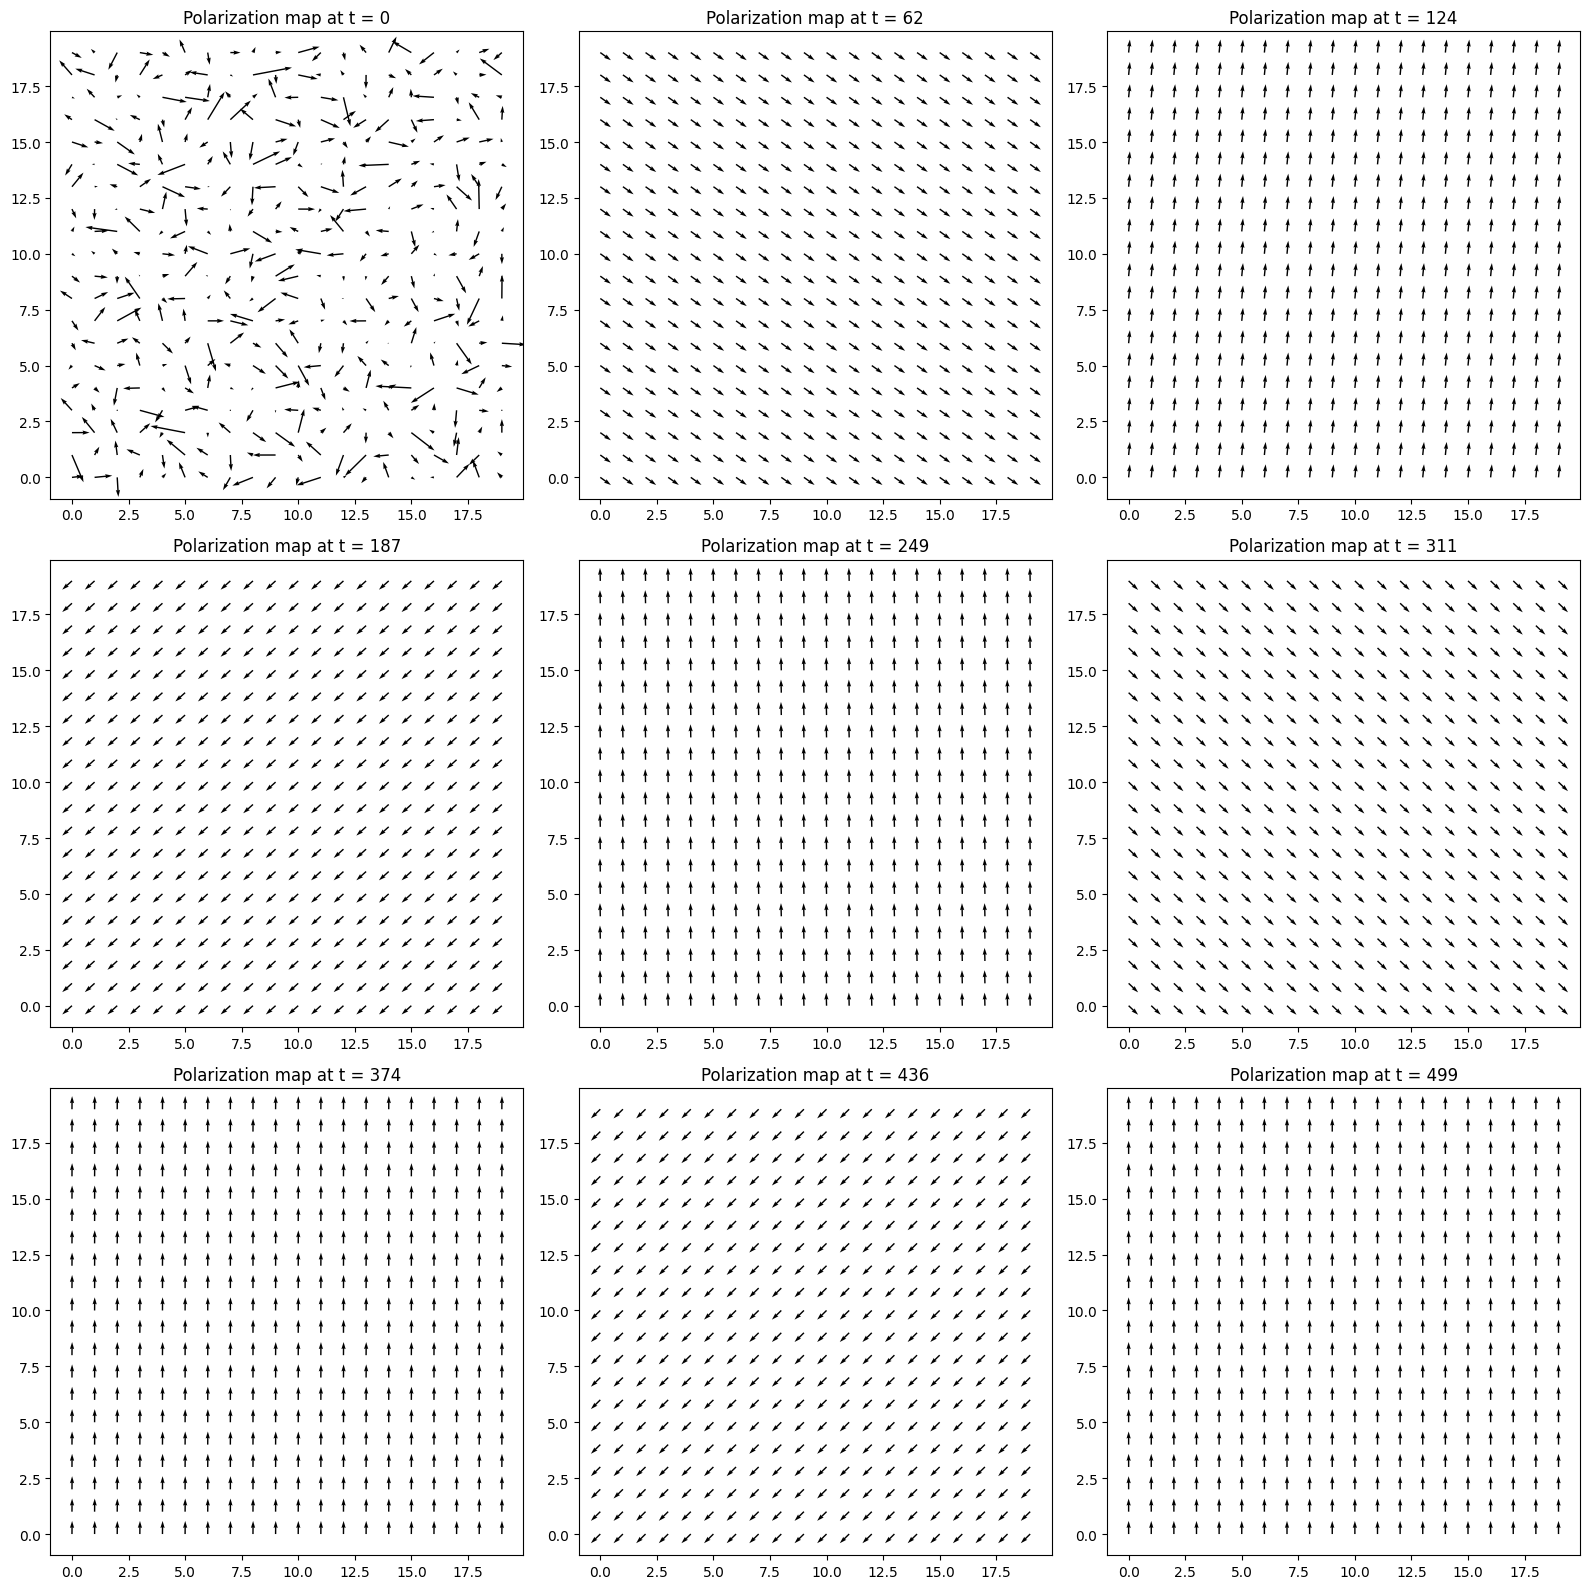

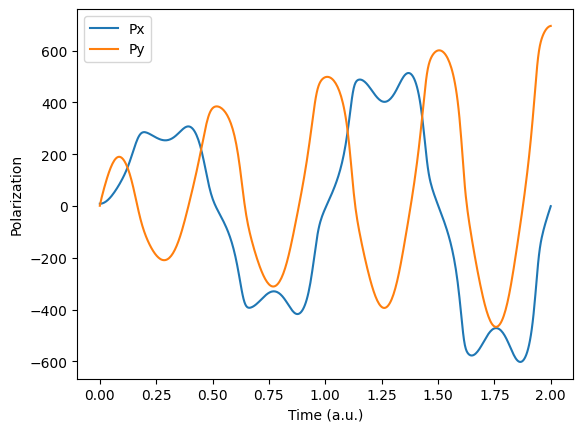

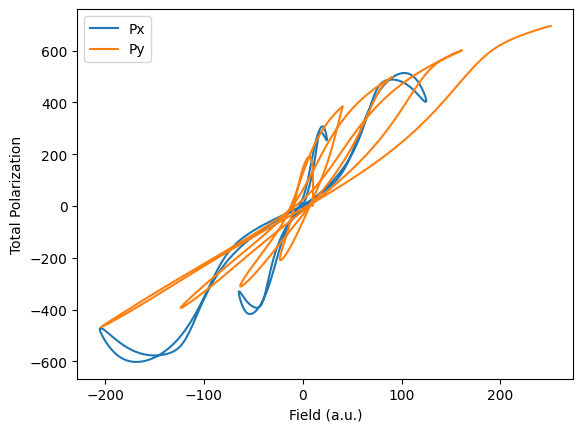

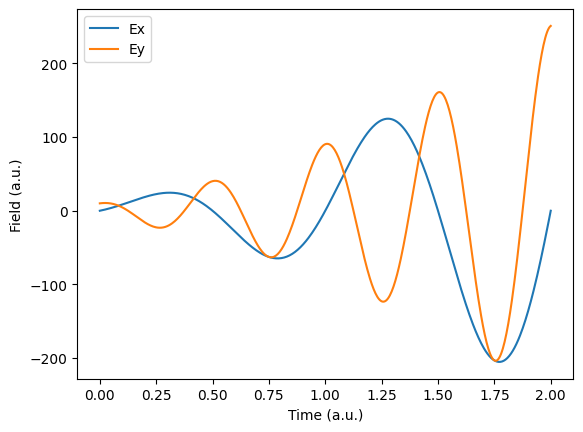

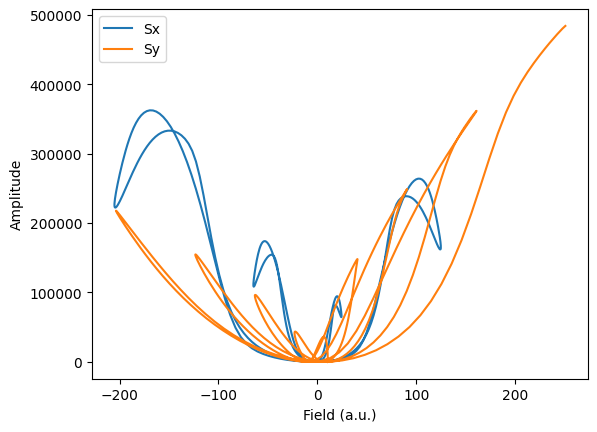

In [ ]:
sim = Ferro2DSim(n=20, time_vec = time_vec, appliedE= applied_field,
                 mode = 'tetragonal', init = 'random')
sim.runSim()
sim.plot_quiver()
sim.plot_summary()

## Adding Custom Defects

We can also add defects to the simulation easily.

### Random Field Effects
Defects can interact with the lattice through field effects (no elastic considerations in this model whatsoever). The simulation expects defects to be entered in as a list of length (n x n) with each element being a tuple $(RF_x, RF_y)$. The units of the $RF_x$ and $RF_y$ are, as with the applied field, multiples of the nominal coercive field (set by the simulations alpha and beta values in the Landau expansion - that can also be changed if you so wish!).

### Random Bond Effects
We can also add defects that produce random-bond disorder: in this case, the coupling constant k is no longer uniform, but spatially dependent. So, k should now be provided as a list of size (n x n). The Default is a list of length (n x n) with all elements set to 1.0.

### Screening effects
Finally, we note that depolarization effects are considered in the model as a uniform constant multipled by the total polarization. However, we can alter this by assuming some screening (e.g., from migration of internal charges, or band bending etc.). The simulation then expects a list of length (n x n) with each element equal to the factor that multiples the total polarization. The Default is set to 0.0 at all sites.

In [ ]:
n = 20 #lattice size
time_vec = np.linspace(0,4,500)

defect_list = []
for row in range(n):
    for col in range(n):
        Efx = 0.01
        Efy = 0.01
        #We place defects every fifth row and 2nd column
        if row%5==0 and col%10==0: Efy = np.random.normal(loc = 15.5, scale = 0.1)

        defect_list.append((Efx, Efy))
defect_list = np.array(defect_list)


#Let's add some random bond disorder. Here we will assume the random bond disorder
#is just a small noise term on teh existing constant value
k = [np.random.normal(loc=1.0,scale = 0.1) for ind in range(n*n)]

#Finally, let's also play with the depolarization. In this case it is going to be random.
dep_alpha = [np.random.uniform(low=0.4, high= 0.8) for ind in range(n*n)]

#Let's just have a sinusoidal field
Evec_x = 10*np.ones(len(time_vec))
Evec_y = 190*np.sin(2*np.pi*time_vec)
applied_field = np.vstack((Evec_x, Evec_y)).T

In [ ]:
sim = Ferro2DSim(n=n,
                 time_vec = time_vec,
                 appliedE=applied_field,
                 defects=defect_list,
                 k=k,
                 dep_alpha = dep_alpha,
                 mode = 'tetragonal')

---Performing simulation---


100%|██████████| 498/498 [00:20<00:00, 24.03it/s]


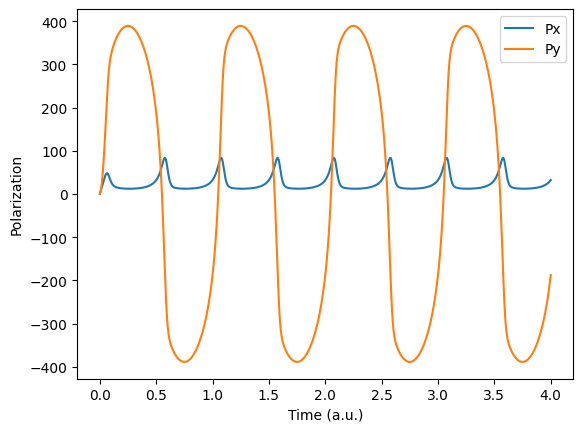

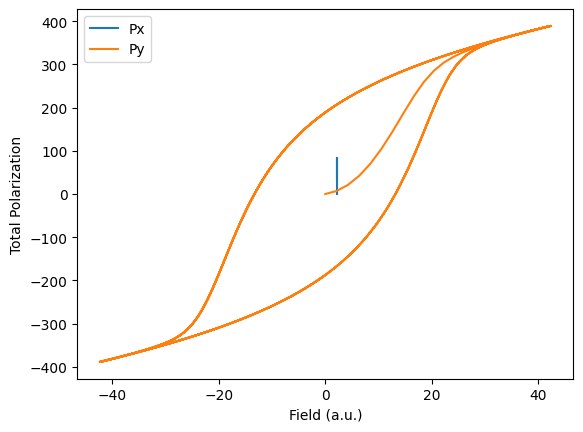

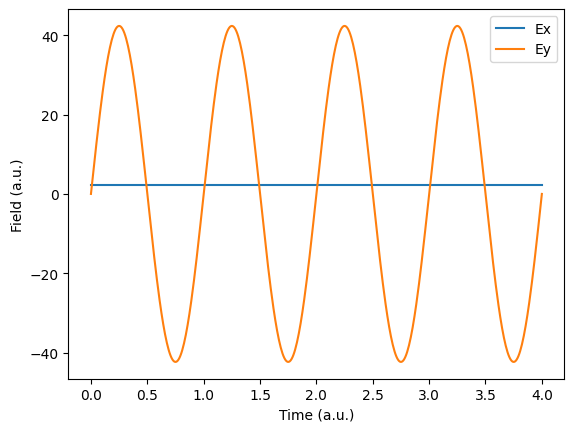

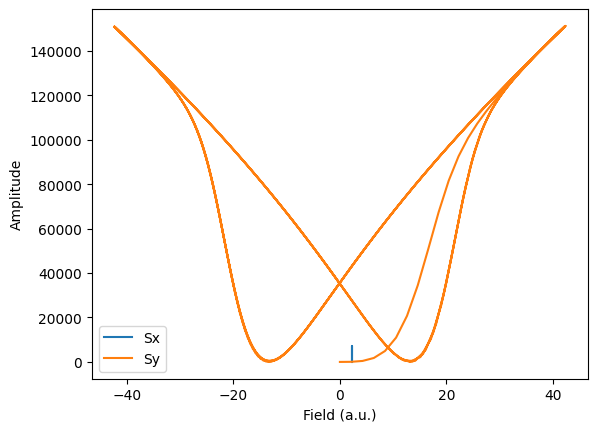

In [ ]:
sim.runSim()
sim.plot_summary()

## "Domain" structures

In [ ]:
def ferrosim_calc1(patch,
                  gamma = 30,
                  defect_field = (30,.01),
                  c_const = 1.1,
                  Eamp = (0, 2),
                  time_vec_length = 3000,
                  dep_alpha = 1E-9):
  #tiem vec
  time_vec = np.linspace(0,2,time_vec_length)
  flat_patch = np.array(patch.flatten())

  #defect field
  Efx, Efy = defect_field

  defect_list = np.zeros((len(flat_patch),2))#np.ones((len(flat_patch),2))*1E-6
  defect_list[flat_patch==0] = (Efx, 0)
  defect_list[flat_patch!=0] =  np.array([np.zeros(len(flat_patch[flat_patch!=0])), -flat_patch[flat_patch!=0]*Efy]).T

  #coupling constant
  k = np.zeros(len(flat_patch))
  k[flat_patch!=0] = c_const

  #applied field
  Evec_x = Eamp[0]*np.ones(len(time_vec))
  Evec_y = Eamp[1]*np.sin(2*np.pi*time_vec)
  applied_field = np.vstack((Evec_x, Evec_y)).T

  #initial P
  init_p  = np.zeros((ws,ws,2))#np.random.uniform(low = -0.2, high = 0.2, size = (ws,ws,2))*1.0E-9

  init_p[:,:,0][patch==0] = 1
  init_p[:,:,1][patch!=0] = patch[patch!=0]*.5

  sim = Ferro2DSim(n=ws,
                  time_vec = time_vec,
                  appliedE=applied_field,
                  defects=defect_list,
                  k=k,
                  dep_alpha = dep_alpha,
                  mode = 'tetragonal',
                  gamma=gamma,
                  initial_p = init_p,)

  sim.runSim();

  return (applied_field.T, sim.results['Polarization'])


def res_pattern(k, stripe_frequency, phase, size=(12,12)):
  c_domain_pattern = c_domain(k, size=size)
  a_domain_pattern = striped_pattern(stripe_frequency, phase, size=size)
  res = (c_domain_pattern*2-1) * (~a_domain_pattern)
  return res, c_domain_pattern, a_domain_pattern

def c_domain(k, size=(12,12)):
  a_pattern = np.array([[1 if (i-k < j) else 0 for j in range(size[0])] for i in range(size[1])])
  return a_pattern.astype(bool)

def striped_pattern(stripe_frequency, phase, size=(12,12), stripe_width=2):
  pattern = np.zeros(size, dtype=int)

  for i in range(size[0]):
      for j in range(size[1]):
          if ((i + j) // stripe_width + phase) % stripe_frequency == 0:
              pattern[i, j] = 1

  return pattern.astype(bool)

def shoelace_formula(x, y):
    return 0.5 * np.abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))

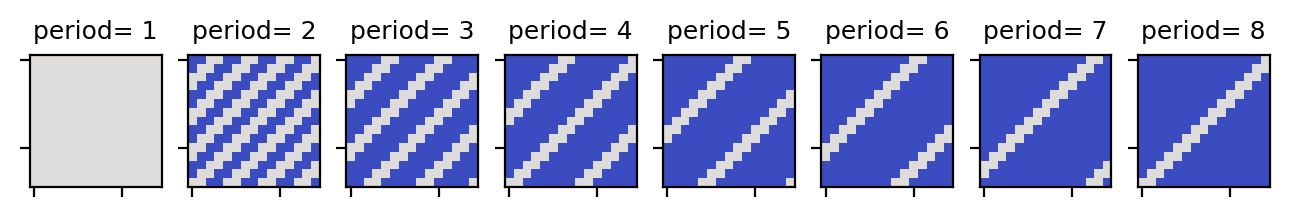

In [ ]:
ws = 15

sf = np.arange(1,9)

patterns = []
for f in sf:
  patterns.append(res_pattern(-15, f, 1, size=(ws,ws)))


fig, ax = plt.subplots(1, len(patterns), figsize=(len(patterns), 1.2), dpi=200)

for i,p in enumerate(patterns):
  ax[i].imshow(p[0], vmin=-1, vmax=1, cmap='coolwarm')
  ax[i].tick_params(labelleft=False, labelbottom=False)
  ax[i].set_title(f"period= {sf[i]}", fontsize=9)

In [ ]:
pol_ar = []

for i,p in enumerate(patterns):
  v, pol = ferrosim_calc1(p[0],
                  gamma = 30, #kinetic coefficient in Landau-Khalatnikov equation (~wall mobility)
                  defect_field = (30,.1),
                  c_const = 0, #coupling constant
                  Eamp = (0, 2), #amplitude of the applied voltage
                  time_vec_length = 2000, #number of the time steps, we always apply 2 sin period
                  dep_alpha = .3 #depolarization constant
                          )
  pol_ar.append(pol)

pol_ar = np.array(pol_ar) #polarization hysteresis loops

---Performing simulation---


100%|██████████| 1998/1998 [00:30<00:00, 65.67it/s]


---Performing simulation---


100%|██████████| 1998/1998 [00:34<00:00, 57.91it/s]


---Performing simulation---


...

100%|██████████| 1998/1998 [00:41<00:00, 47.97it/s]


---Performing simulation---


100%|██████████| 1998/1998 [00:33<00:00, 59.51it/s]


---Performing simulation---


100%|██████████| 1998/1998 [00:30<00:00, 65.76it/s]


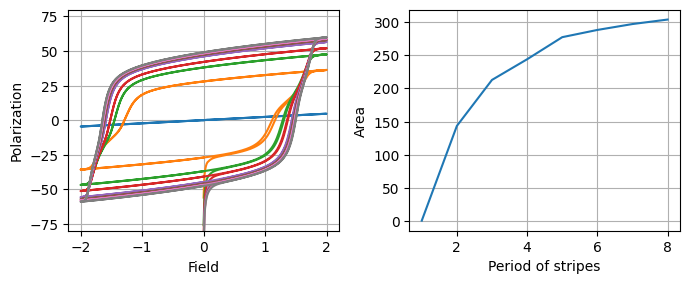

In [ ]:
loop_area = np.array([])
fig, ax = plt.subplots(1,2, figsize=(7,3))

for pp in pol_ar:
  loop_area = np.append(loop_area, float(shoelace_formula(v[1,-1000:], pp[1, -1000:]))) #
  ax[0].plot(v[1], pp[1])

ax[0].grid()
ax[0].set_ylabel("Polarization")
ax[0].set_xlabel("Field")
ax[0].set_ylim(-80,80)

ax[1].plot(sf, loop_area)
ax[1].grid()
ax[1].set_ylabel('Area')
ax[1].set_xlabel('Period of stripes')

plt.tight_layout()

# Hackathon Day 5

I would like to use genetic algorithm that will allow me to create defect population that will maximize the area under the hysteresis loop. I will assume that defects have all the same energy, and will only play with the distributions. My steps will be:
- create the function that does the cross-over and mutation.
- create defect population
- evolve using 10 best of 20 attempts (top tier)

## Building the mutation algorithm

In [ ]:
import numpy as np

rng = np.random.default_rng()

# ---------- Init, mutation, crossover, repair ----------

def init_population(N, M, p):
    target_ones = int(round(p * M))
    pop = np.zeros((N, M), dtype=np.int8)
    for i in range(N):
        idx = rng.choice(M, size=target_ones, replace=False)
        pop[i, idx] = 1
    return pop, target_ones


def mutate(individual, n_swaps=1):
    M = len(individual)
    for _ in range(n_swaps):
        i, j = rng.integers(0, M, size=2)
        if individual[i] != individual[j]:
            individual[i], individual[j] = individual[j], individual[i]
    return individual


def crossover(parent1, parent2, k=None):
    M = len(parent1)
    if k is None:
        k = rng.integers(1, M)   # 1..M-1
    else:
        k = max(1, min(k, M-1))

    start = rng.integers(0, M - k + 1)
    end = start + k

    child1 = parent1.copy()
    child2 = parent2.copy()
    child1[start:end], child2[start:end] = parent2[start:end], parent1[start:end]
    return child1, child2


def repair(individual, target_ones):
    current_ones = individual.sum()
    if current_ones == target_ones:
        return individual

    if current_ones > target_ones:
        # too many 1s → flip some 1→0
        ones_idx = np.where(individual == 1)[0]
        n_flip = current_ones - target_ones
        flip_idx = rng.choice(ones_idx, size=n_flip, replace=False)
        individual[flip_idx] = 0
    else:
        # too few 1s → flip some 0→1
        zeros_idx = np.where(individual == 0)[0]
        n_flip = target_ones - current_ones
        flip_idx = rng.choice(zeros_idx, size=n_flip, replace=False)
        individual[flip_idx] = 1

    return individual


In [ ]:
def genetic_algorithm(
    fitness_fn,
    N=10,
    M=20,
    p=0.3,
    n_generations=100,
    crossover_rate=0.9,
    mutation_rate=0.2,
    n_swaps_mutation=1,
):
    # initialize
    pop, target_ones = init_population(N, M, p)

    best_fitness_history = []
    mean_fitness_history = []
    median_fitness_history = []
    best_individuals = []

    for gen in range(n_generations):

        print(f"Generation {gen+1}/{n_generations}")

        # evaluate fitness
        fitness = np.array([fitness_fn(ind) for ind in pop])

        # log stats
        best_idx = fitness.argmax()
        best_fitness = fitness[best_idx]
        mean_fitness = fitness.mean()
        median_fitness = np.median(fitness)

        best_fitness_history.append(best_fitness)
        mean_fitness_history.append(mean_fitness)
        median_fitness_history.append(median_fitness)
        best_individuals.append(pop[best_idx].copy())

        # selection (simple fitness-proportional selection)
        probs = fitness - fitness.min() + 1e-9
        probs = probs / probs.sum()

        new_pop = []

        while len(new_pop) < N:
            # select parents
            i1, i2 = rng.choice(N, size=2, p=probs, replace=False)
            parent1, parent2 = pop[i1], pop[i2]

            # crossover
            if rng.random() < crossover_rate:
                child1, child2 = crossover(parent1, parent2)
                child1 = repair(child1, target_ones)
                child2 = repair(child2, target_ones)
            else:
                child1, child2 = parent1.copy(), parent2.copy()

            # mutation
            if rng.random() < mutation_rate:
                child1 = mutate(child1, n_swaps=n_swaps_mutation)
            if rng.random() < mutation_rate:
                child2 = mutate(child2, n_swaps=n_swaps_mutation)

            new_pop.append(child1)
            if len(new_pop) < N:
                new_pop.append(child2)

        pop = np.array(new_pop, dtype=np.int8)

    # final evaluation
    fitness = np.array([fitness_fn(ind) for ind in pop])
    best_idx = fitness.argmax()
    best_ind = pop[best_idx]
    best_fit = fitness[best_idx]

    history = {
        "best_fitness": np.array(best_fitness_history),
        "mean_fitness": np.array(mean_fitness_history),
        "median_fitness": np.array(median_fitness_history),
        "best_individuals": np.array(best_individuals),  # shape (n_generations, M)
    }

    return best_ind, best_fit, pop, fitness, history


Here, our fitness function is the number of ajacent 1-1 pairs

In [ ]:
def fitness_fn(individual):
    # Example: maximize number of adjacent 1-1 pairs
    return np.sum(individual[:-1] * individual[1:])


Generation 1/100
Generation 2/100
Generation 3/100
Generation 4/100
Generation 5/100
Generation 6/100
Generation 7/100
Generation 8/100
Generation 9/100
Generation 10/100
Generation 11/100
Generation 12/100
Generation 13/100
Generation 14/100
Generation 15/100
Generation 16/100
Generation 17/100
Generation 18/100
Generation 19/100
Generation 20/100
Generation 21/100
Generation 22/100
Generation 23/100
Generation 24/100
Generation 25/100
Generation 26/100
Generation 27/100
Generation 28/100
Generation 29/100
Generation 30/100
Generation 31/100
Generation 32/100
Generation 33/100
Generation 34/100
Generation 35/100
Generation 36/100
Generation 37/100
Generation 38/100
Generation 39/100
Generation 40/100
Generation 41/100
Generation 42/100
Generation 43/100
Generation 44/100
Generation 45/100
Generation 46/100
Generation 47/100
Generation 48/100
Generation 49/100
Generation 50/100
Generation 51/100
Generation 52/100
Generation 53/100
Generation 54/100
Generation 55/100
Generation 56/100
G

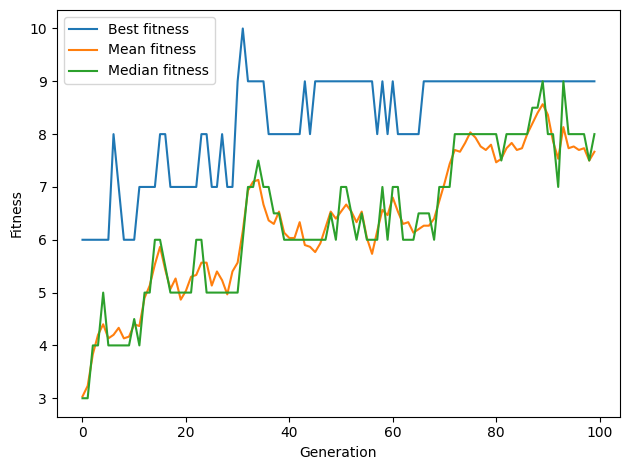

In [ ]:
import matplotlib.pyplot as plt

best, best_fit, pop, fitness, history = genetic_algorithm(
    fitness_fn,
    N=30,
    M=40,
    p=0.3,
    n_generations=100,
    crossover_rate=0.9,
    mutation_rate=0.3,
    n_swaps_mutation=2,
)

gens = np.arange(len(history["best_fitness"]))

plt.figure()
plt.plot(gens, history["best_fitness"], label="Best fitness")
plt.plot(gens, history["mean_fitness"], label="Mean fitness")
plt.plot(gens, history["median_fitness"], label="Median fitness")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend()
plt.tight_layout()
plt.show()


Now we make our fitness function the number of triplets

In [ ]:
def fitness_fn(individual):
    """
    Fitness = number of (possibly overlapping) triplets '111' in the bitstring.
    Example:
        1110 -> 1
        1111 -> 2  (positions 0–2 and 1–3)
    """
    x = individual
    if len(x) < 3:
        return 0
    return int(np.sum(x[:-2] * x[1:-1] * x[2:]))


In [ ]:
best, best_fit, pop, fitness, history = genetic_algorithm(
    fitness_fn,
    N=30,
    M=40,
    p=0.3,
    n_generations=100,
    crossover_rate=0.9,
    mutation_rate=0.3,
    n_swaps_mutation=2,
)


Generation 1/100
Generation 2/100
Generation 3/100
Generation 4/100
Generation 5/100
Generation 6/100
Generation 7/100
Generation 8/100
Generation 9/100
Generation 10/100
Generation 11/100
Generation 12/100
Generation 13/100
Generation 14/100
Generation 15/100
Generation 16/100
Generation 17/100
Generation 18/100
Generation 19/100
Generation 20/100
Generation 21/100
Generation 22/100
Generation 23/100
Generation 24/100
Generation 25/100
Generation 26/100
Generation 27/100
Generation 28/100
Generation 29/100
Generation 30/100
Generation 31/100
Generation 32/100
Generation 33/100
Generation 34/100
Generation 35/100
Generation 36/100
Generation 37/100
Generation 38/100
Generation 39/100
Generation 40/100
Generation 41/100
Generation 42/100
Generation 43/100
Generation 44/100
Generation 45/100
Generation 46/100
Generation 47/100
Generation 48/100
Generation 49/100
Generation 50/100
Generation 51/100
Generation 52/100
Generation 53/100
Generation 54/100
Generation 55/100
Generation 56/100
G

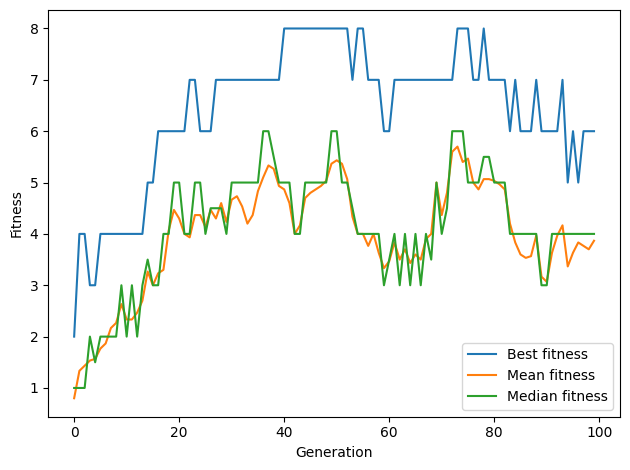

In [ ]:
gens = np.arange(len(history["best_fitness"]))

plt.figure()
plt.plot(gens, history["best_fitness"], label="Best fitness")
plt.plot(gens, history["mean_fitness"], label="Mean fitness")
plt.plot(gens, history["median_fitness"], label="Median fitness")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend()
plt.tight_layout()
plt.show()

Now let's make fitness function to be the digital value

In [ ]:
import numpy as np

def fitness_fn(individual):
    """
    Fitness = decimal value of the binary vector.
    Example:
        [1,0,1] -> 5
        [1,1,1] -> 7
    Assumes individual[0] is the most significant bit.
    """
    bits = individual.astype(int)
    M = len(bits)
    powers = 2 ** np.arange(M-1, -1, -1)  # [2^(M-1), ..., 2^0]
    return int(np.dot(bits, powers))


In [ ]:
best, best_fit, pop, fitness, history = genetic_algorithm(
    fitness_fn,
    N=30,
    M=40,
    p=0.3,
    n_generations=100,
    crossover_rate=0.9,
    mutation_rate=0.3,
    n_swaps_mutation=2,
)

Generation 1/100
Generation 2/100
Generation 3/100
Generation 4/100
Generation 5/100
Generation 6/100
Generation 7/100
Generation 8/100
Generation 9/100
Generation 10/100
Generation 11/100
Generation 12/100
Generation 13/100
Generation 14/100
Generation 15/100
Generation 16/100
Generation 17/100
Generation 18/100
Generation 19/100
Generation 20/100
Generation 21/100
Generation 22/100
Generation 23/100
Generation 24/100
Generation 25/100
Generation 26/100
Generation 27/100
Generation 28/100
Generation 29/100
Generation 30/100
Generation 31/100
Generation 32/100
Generation 33/100
Generation 34/100
Generation 35/100
Generation 36/100
Generation 37/100
Generation 38/100
Generation 39/100
Generation 40/100
Generation 41/100
Generation 42/100
Generation 43/100
Generation 44/100
Generation 45/100
Generation 46/100
Generation 47/100
Generation 48/100
Generation 49/100
Generation 50/100
Generation 51/100
Generation 52/100
Generation 53/100
Generation 54/100
Generation 55/100
Generation 56/100
G

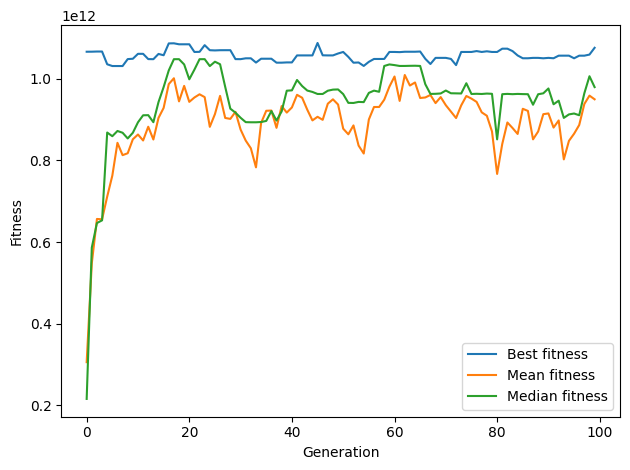

In [ ]:
gens = np.arange(len(history["best_fitness"]))

plt.figure()
plt.plot(gens, history["best_fitness"], label="Best fitness")
plt.plot(gens, history["mean_fitness"], label="Mean fitness")
plt.plot(gens, history["median_fitness"], label="Median fitness")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend()
plt.tight_layout()
plt.show()

## FerroSIM implementation

Redefnie our GA so it stores best examples

In [ ]:
def genetic_algorithm(
    fitness_fn,
    N=10,
    M=20,
    p=0.3,
    n_generations=100,
    crossover_rate=0.9,
    mutation_rate=0.2,
    n_swaps_mutation=1,
):
    # initialize
    pop, target_ones = init_population(N, M, p)

    best_fitness_history = []
    mean_fitness_history = []
    median_fitness_history = []
    best_individuals = []
    populations_history = []   # <--- NEW

    for gen in range(n_generations):
        print(f"Generation {gen+1}/{n_generations}")
        # evaluate fitness
        fitness = np.array([fitness_fn(ind) for ind in pop])

        # log stats for this generation
        best_idx = fitness.argmax()
        best_fitness = fitness[best_idx]
        mean_fitness = fitness.mean()
        median_fitness = np.median(fitness)

        best_fitness_history.append(best_fitness)
        mean_fitness_history.append(mean_fitness)
        median_fitness_history.append(median_fitness)
        best_individuals.append(pop[best_idx].copy())
        populations_history.append(pop.copy())    # <--- store whole generation

        # selection (simple fitness-proportional selection)
        probs = fitness - fitness.min() + 1e-9
        probs = probs / probs.sum()

        new_pop = []

        while len(new_pop) < N:
            # select parents
            i1, i2 = rng.choice(N, size=2, p=probs, replace=False)
            parent1, parent2 = pop[i1], pop[i2]

            # crossover
            if rng.random() < crossover_rate:
                child1, child2 = crossover(parent1, parent2)
                child1 = repair(child1, target_ones)
                child2 = repair(child2, target_ones)
            else:
                child1, child2 = parent1.copy(), parent2.copy()

            # mutation
            if rng.random() < mutation_rate:
                child1 = mutate(child1, n_swaps=n_swaps_mutation)
            if rng.random() < mutation_rate:
                child2 = mutate(child2, n_swaps=n_swaps_mutation)

            new_pop.append(child1)
            if len(new_pop) < N:
                new_pop.append(child2)

        pop = np.array(new_pop, dtype=np.int8)

    # final evaluation
    fitness = np.array([fitness_fn(ind) for ind in pop])
    best_idx = fitness.argmax()
    best_ind = pop[best_idx]
    best_fit = fitness[best_idx]

    history = {
        "best_fitness": np.array(best_fitness_history),
        "mean_fitness": np.array(mean_fitness_history),
        "median_fitness": np.array(median_fitness_history),
        "best_individuals": np.array(best_individuals),   # (G, M)
        "populations": np.array(populations_history),     # (G, N, M)
    }

    return best_ind, best_fit, pop, fitness, history


This sets our model. Let's not change it.

In [ ]:
n = 6 #lattice size
time_vec = np.linspace(0,4,500)

#Let's add some random bond disorder. Here we will assume the random bond disorder
#is just a small noise term on teh existing constant value
k = [np.random.normal(loc=1.0,scale = 0.1) for ind in range(n*n)]

#Finally, let's also play with the depolarization. In this case it is going to be random.
dep_alpha = [np.random.uniform(low=0.4, high= 0.8) for ind in range(n*n)]

#Let's just have a sinusoidal field
Evec_x = 10*np.ones(len(time_vec))
Evec_y = 190*np.sin(2*np.pi*time_vec)
applied_field = np.vstack((Evec_x, Evec_y)).T

In [ ]:
import numpy as np
rng = np.random.default_rng()

def make_chromosome(n, p):
    """
    n : grid size (n x n)
    p : fraction of 1s (defects)
    """
    M = n * n
    target_ones = int(round(p * M))

    chrom = np.zeros(M, dtype=np.int8)
    ones_idx = rng.choice(M, size=target_ones, replace=False)
    chrom[ones_idx] = 1
    return chrom

p = 0.25
chromosome = make_chromosome(n, p)
print("Chromosome (1D):", chromosome)
print("Reshaped (n x n):\n", chromosome.reshape(n, n))



Chromosome (1D): [0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 1 0]
Reshaped (n x n):
 [[0 0 0 0 0 0]
 [1 1 0 0 0 0]
 [0 0 1 0 1 1]
 [0 0 0 0 0 1]
 [1 0 0 1 0 0]
 [0 0 0 0 1 0]]


In [ ]:
def make_defect_list_from_chromosome(chromosome, n,
                                     base_Efx=0.01, base_Efy=0.01,
                                     defect_loc=15.5, defect_scale=0.1):
    """
    chromosome: 1D array of length n*n with 0/1 (GA individual)
    n         : grid size (n x n)

    Returns:
        defect_list: array of shape (n*n, 2) with (Efx, Efy) at each site
    """
    chromosome = np.asarray(chromosome).astype(int)
    assert chromosome.size == n * n, "Chromosome length must be n*n"

    defect_list = []

    for row in range(n):
        for col in range(n):
            idx = row * n + col  # map (row, col) -> position in chromosome

            Efx = base_Efx
            Efy = base_Efy

            # If gene = 1, place a defect here
            if chromosome[idx] == 1:
                Efy = np.random.normal(loc=defect_loc, scale=defect_scale)

            defect_list.append((Efx, Efy))

    return np.array(defect_list)


In [ ]:
defect_list = make_defect_list_from_chromosome(chromosome, n,
                                     base_Efx=0.01, base_Efy=0.01,
                                     defect_loc=15.5, defect_scale=0.1)

sim = Ferro2DSim(n=n,
                 time_vec = time_vec,
                 appliedE=applied_field,
                 defects=defect_list,
                 k=k,
                 dep_alpha = dep_alpha,
                 mode = 'tetragonal')

---Performing simulation---


100%|██████████| 498/498 [00:01<00:00, 496.39it/s]


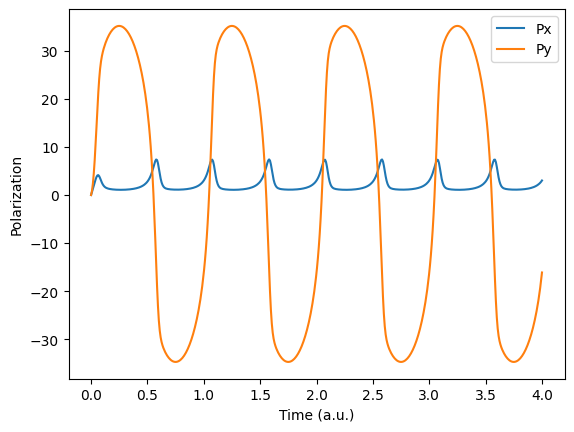

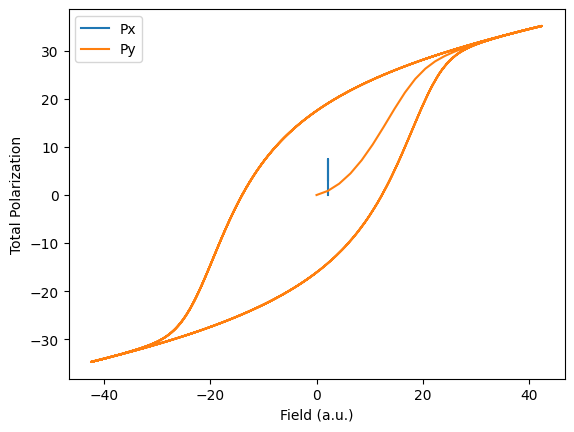

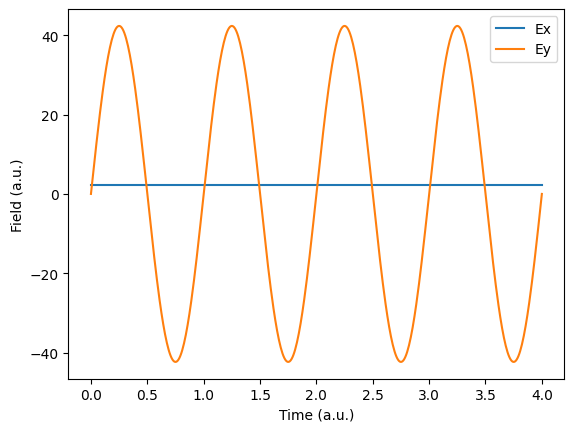

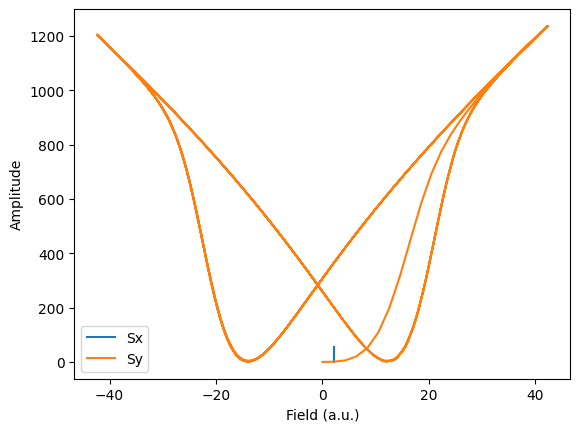

In [ ]:
sim.runSim()
sim.plot_summary()

In [ ]:
sim.results.keys()

dict_keys(['Polarization', 'dPolarization'])

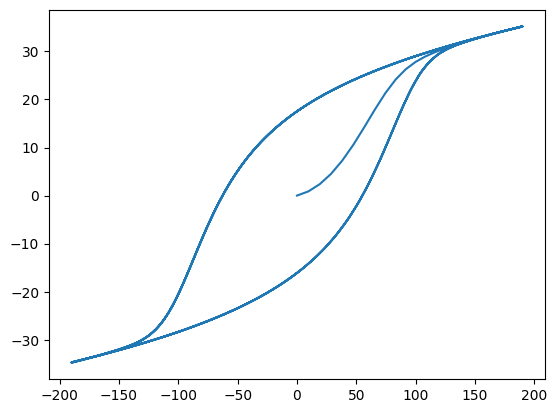

In [ ]:
plt.plot(applied_field[:,1], sim.results['Polarization'].T[:,1])

In [ ]:
E = applied_field[:, 1]                         # field
P = sim.results['Polarization'].T[:, 1]         # polarization

def hysteresis_area_PE(E, P):
    """
    Compute hysteresis loop area in P-E plane using ∮ P dE.
    E, P: 1D arrays ordered along the loop (e.g., time order).
    Returns |area|.
    """
    E = np.asarray(E)
    P = np.asarray(P)

    # Ensure closed loop: duplicate first point at end if needed
    if E[0] != E[-1] or P[0] != P[-1]:
        E = np.concatenate([E, E[:1]])
        P = np.concatenate([P, P[:1]])

    dE = np.diff(E)
    P_mid = 0.5 * (P[:-1] + P[1:])  # midpoint rule (trapezoid)

    A = np.sum(P_mid * dE)          # ∑ P_mid * dE  ≈ ∮ P dE
    return abs(A)


In [ ]:
area = hysteresis_area_PE(applied_field[:, 1],
                          sim.results['Polarization'].T[:, 1])
print("Loop area =", area)


Loop area = 19186.49908751431


Let's start with maximum polarization being fitness function

In [ ]:
def fitness_fn(individual):
    bits = individual.astype(int)
    defect_list = make_defect_list_from_chromosome(bits, n,
                                                   base_Efx=0.01, base_Efy=0.01, defect_loc=15.5, defect_scale=0.1)
    sim = Ferro2DSim(n=n, time_vec = time_vec,
                     appliedE=applied_field,defects=defect_list,
                     k=k, dep_alpha = dep_alpha, mode = 'tetragonal')
    sim.runSim();

    area = hysteresis_area_PE(applied_field[:, 1],
                          sim.results['Polarization'].T[:, 1])

    return(area) #, sim.results['Polarization'].max())

In [ ]:
best, best_fit, pop, fitness, history = genetic_algorithm(
    fitness_fn,
    N=15,
    M=n * n,
    p=0.3,
    n_generations=10,
    crossover_rate=0.9,
    mutation_rate=0.3,
    n_swaps_mutation=2,
)

---Performing simulation---


100%|██████████| 498/498 [00:00<00:00, 510.77it/s]


---Performing simulation---


100%|██████████| 498/498 [00:01<00:00, 280.75it/s]


---Performing simulation---


...

100%|██████████| 498/498 [00:00<00:00, 526.31it/s]


---Performing simulation---


100%|██████████| 498/498 [00:00<00:00, 516.63it/s]


---Performing simulation---


100%|██████████| 498/498 [00:00<00:00, 519.10it/s]


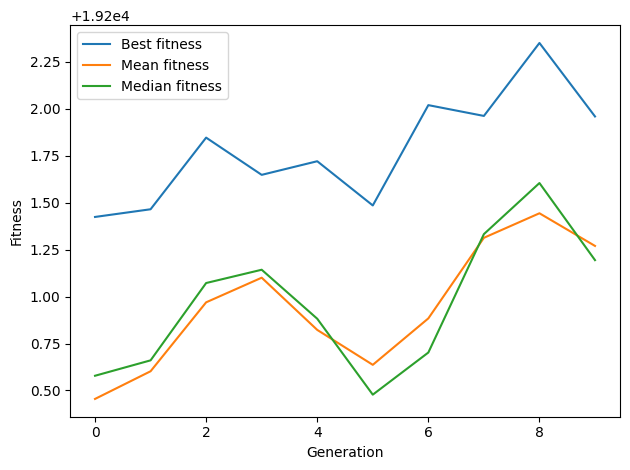

In [ ]:
gens = np.arange(len(history["best_fitness"]))

plt.figure()
plt.plot(gens, history["best_fitness"], label="Best fitness")
plt.plot(gens, history["mean_fitness"], label="Mean fitness")
plt.plot(gens, history["median_fitness"], label="Median fitness")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend()
plt.tight_layout()
plt.show()

Explained variance ratio: [0.3535093  0.24197953]


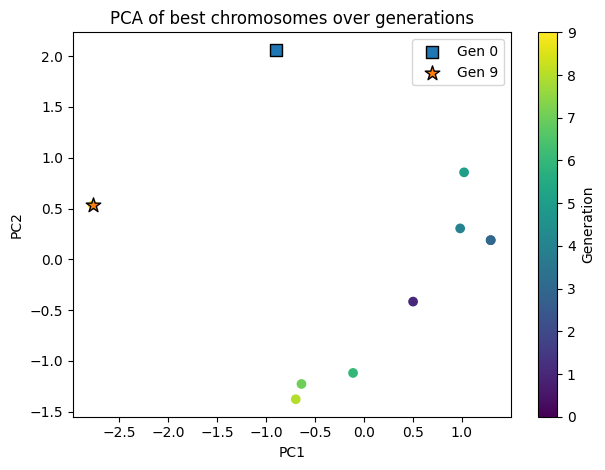

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# best_matrix: shape (n_generations, M)
best_matrix = history["best_individuals"]      # from your GA
n_generations, M = best_matrix.shape

# Optionally center the data (PCA does this internally, but it's fine either way)
# X = best_matrix - best_matrix.mean(axis=0)
X = best_matrix

# ---- PCA ----
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)   # shape (n_generations, 2)

print("Explained variance ratio:", pca.explained_variance_ratio_)

# ---- Plot PCA1 vs PCA2 with generation as color ----
gens = np.arange(n_generations)

plt.figure()
sc = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=gens,
    cmap="viridis"
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of best chromosomes over generations")
cbar = plt.colorbar(sc)
cbar.set_label("Generation")

# Optionally highlight start and end
plt.scatter(X_pca[0, 0], X_pca[0, 1], marker="s", s=80, edgecolor="k", label="Gen 0")
plt.scatter(X_pca[-1, 0], X_pca[-1, 1], marker="*", s=120, edgecolor="k", label=f"Gen {n_generations-1}")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
history["best_individuals"].shape

(10, 36)

Explained variance ratio (PC1, PC2): [0.16779183 0.10082581]


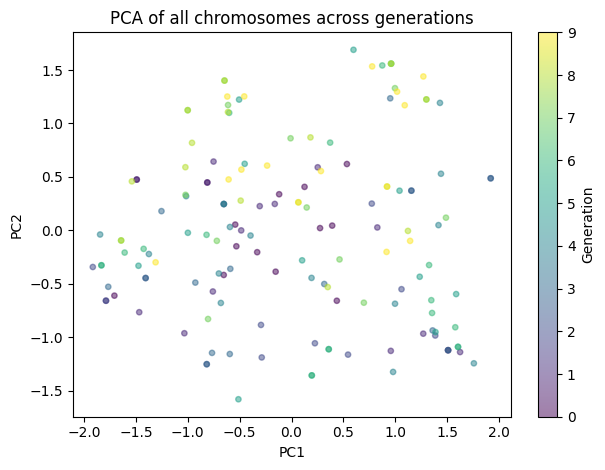

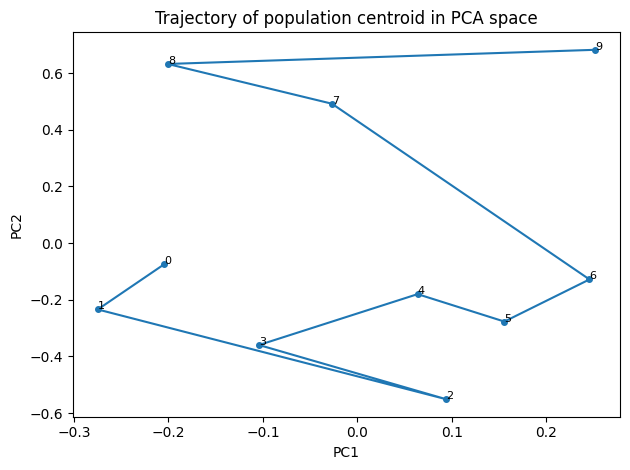

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# populations: shape (n_generations, N, M)
populations = history["populations"]
n_generations, N, M = populations.shape

# ---- Flatten to (n_generations * N, M) and build generation labels ----
X = populations.reshape(-1, M)               # all chromosomes
gen_labels = np.repeat(np.arange(n_generations), N)  # length = n_generations * N

# ---- PCA ----
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)                 # shape (n_generations * N, 2)

print("Explained variance ratio (PC1, PC2):", pca.explained_variance_ratio_)

# ---- Scatter plot: PC1 vs PC2, colored by generation ----
plt.figure()
sc = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=gen_labels,
    cmap="viridis",
    s=15,
    alpha=0.5,
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of all chromosomes across generations")
cbar = plt.colorbar(sc)
cbar.set_label("Generation")
plt.tight_layout()
plt.show()

# ---- Optional: show trajectory of population centroids in PCA space ----
# reshape back to (G, N, 2)
X_pca_reshaped = X_pca.reshape(n_generations, N, 2)
centroids = X_pca_reshaped.mean(axis=1)   # (G, 2)

plt.figure()
plt.plot(centroids[:, 0], centroids[:, 1], "-o", markersize=4)
for g in range(0, n_generations, max(1, n_generations // 10)):
    plt.text(centroids[g, 0], centroids[g, 1], str(g), fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Trajectory of population centroid in PCA space")
plt.tight_layout()
plt.show()


In [ ]:
populations.shape

(10, 15, 36)

## Added elitism

In [ ]:
import numpy as np
rng = np.random.default_rng()

def genetic_algorithm_elite(
    fitness_fn,
    N=20,
    M=20,
    p=0.3,
    n_generations=20,
    elite_fraction=0.2,      # top 20% kept as parents
    mutation_fraction=0.5,   # 50% mutants, 50% crossovers
    n_swaps_mutation=1,
):
    """
    GA with truncation selection and elite-only reproduction.

    - Each generation:
        * Evaluate all N individuals.
        * Select top elite_fraction * N as elites.
        * Next generation:
            - ~mutation_fraction * N mutated clones of elites
            - remaining individuals are crossover children of elites
    - Number of 1s in chromosomes is preserved (via repair).
    - Prints generation number.
    - Stores history, including elites.
    """

    # initialize population
    pop, target_ones = init_population(N, M, p)

    # histories
    best_fitness_history = []
    mean_fitness_history = []
    median_fitness_history = []
    best_individuals = []
    populations_history = []
    elites_history = []          # list of arrays shape (elite_count, M)
    elites_fitness_history = []  # list of arrays shape (elite_count,)

    elite_fraction = float(elite_fraction)
    mutation_fraction = float(mutation_fraction)
    elite_count = max(1, int(np.ceil(elite_fraction * N)))  # fixed per run

    for gen in range(n_generations):
        # ---- Evaluate ----
        fitness = np.array([fitness_fn(ind) for ind in pop])

        # ---- Log stats ----
        best_idx = fitness.argmax()
        best_fitness = fitness[best_idx]
        mean_fitness = fitness.mean()
        median_fitness = np.median(fitness)

        best_fitness_history.append(best_fitness)
        mean_fitness_history.append(mean_fitness)
        median_fitness_history.append(median_fitness)
        best_individuals.append(pop[best_idx].copy())
        populations_history.append(pop.copy())

        # ---- Select elites (truncation) ----
        elite_indices = np.argsort(fitness)[-elite_count:]   # top elite_count
        elites = pop[elite_indices]                          # (elite_count, M)
        elites_fit = fitness[elite_indices]                  # (elite_count,)

        elites_history.append(elites.copy())
        elites_fitness_history.append(elites_fit.copy())

        # ---- Print progress ----
        print(f"Generation {gen+1}/{n_generations} | "
              f"best = {best_fitness:.4g}, mean = {mean_fitness:.4g}")

        # ---- Build next generation from elites ----
        new_pop = []

        # how many mutants vs crossover children
        n_mutants_target = int(round(mutation_fraction * N))
        n_mutants_target = min(max(0, n_mutants_target), N)

        # 1) Mutated clones from elites
        while len(new_pop) < n_mutants_target:
            parent = elites[rng.integers(0, elite_count)]
            child = mutate(parent.copy(), n_swaps=n_swaps_mutation)
            child = repair(child, target_ones)
            new_pop.append(child)

        # 2) Crossover children from elites
        while len(new_pop) < N:
            i1, i2 = rng.integers(0, elite_count, size=2)
            p1, p2 = elites[i1], elites[i2]
            child1, child2 = crossover(p1, p2)
            child1 = repair(child1, target_ones)
            child2 = repair(child2, target_ones)
            new_pop.append(child1)
            if len(new_pop) < N:
                new_pop.append(child2)

        pop = np.array(new_pop, dtype=np.int8)

    # ---- Final evaluation ----
    fitness = np.array([fitness_fn(ind) for ind in pop])
    best_idx = fitness.argmax()
    best_ind = pop[best_idx]
    best_fit = fitness[best_idx]

    history = {
        "best_fitness": np.array(best_fitness_history),
        "mean_fitness": np.array(mean_fitness_history),
        "median_fitness": np.array(median_fitness_history),
        "best_individuals": np.array(best_individuals),        # (G, M)
        "populations": np.array(populations_history),          # (G, N, M)
        "elites": np.array(elites_history),                    # (G, elite_count, M)
        "elites_fitness": np.array(elites_fitness_history),    # (G, elite_count)
    }

    return best_ind, best_fit, pop, fitness, history


In [ ]:
best, best_fit, pop, fitness, history = genetic_algorithm_elite(
    fitness_fn,
    N=20,
    M=n*n,
    p=0.3,
    n_generations=20,
    elite_fraction=0.2,
    mutation_fraction=0.5,
    n_swaps_mutation=2,
)


---Performing simulation---


100%|██████████| 498/498 [00:02<00:00, 174.02it/s]


---Performing simulation---


100%|██████████| 498/498 [00:01<00:00, 264.19it/s]


---Performing simulation---


...

100%|██████████| 498/498 [00:00<00:00, 509.67it/s]


---Performing simulation---


100%|██████████| 498/498 [00:00<00:00, 507.53it/s]


---Performing simulation---


100%|██████████| 498/498 [00:00<00:00, 506.85it/s]


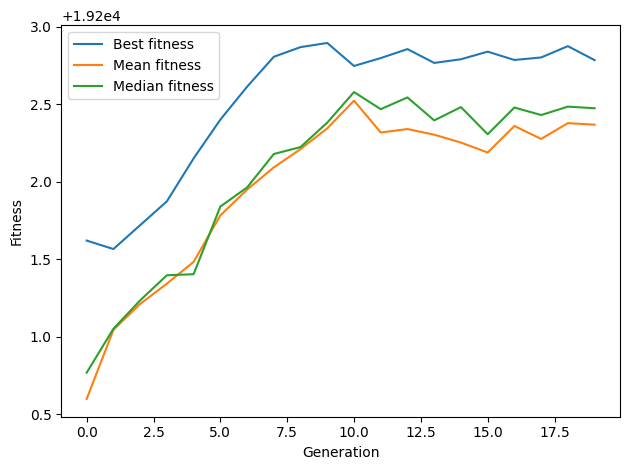

In [ ]:
gens = np.arange(len(history["best_fitness"]))

plt.figure()
plt.plot(gens, history["best_fitness"], label="Best fitness")
plt.plot(gens, history["mean_fitness"], label="Mean fitness")
plt.plot(gens, history["median_fitness"], label="Median fitness")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
history["best_individuals"].shape

(20, 36)

Explained variance ratio (PC1, PC2): [0.34202039 0.16125732]


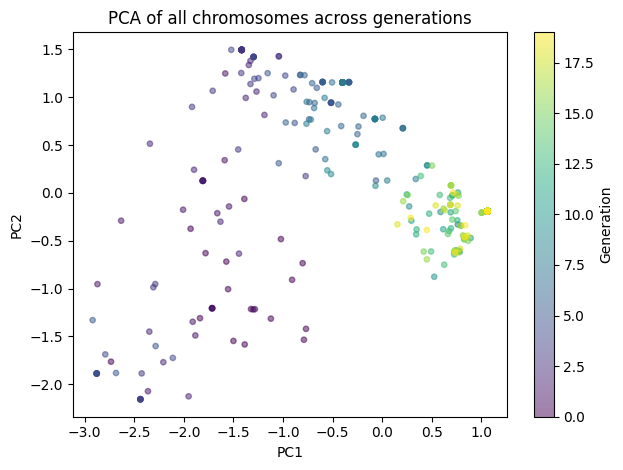

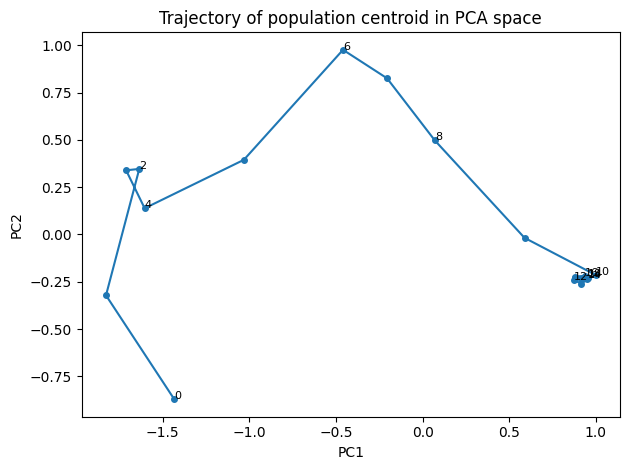

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# populations: shape (n_generations, N, M)
populations = history["populations"]
n_generations, N, M = populations.shape

# ---- Flatten to (n_generations * N, M) and build generation labels ----
X = populations.reshape(-1, M)               # all chromosomes
gen_labels = np.repeat(np.arange(n_generations), N)  # length = n_generations * N

# ---- PCA ----
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)                 # shape (n_generations * N, 2)

print("Explained variance ratio (PC1, PC2):", pca.explained_variance_ratio_)

# ---- Scatter plot: PC1 vs PC2, colored by generation ----
plt.figure()
sc = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=gen_labels,
    cmap="viridis",
    s=15,
    alpha=0.5,
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of all chromosomes across generations")
cbar = plt.colorbar(sc)
cbar.set_label("Generation")
plt.tight_layout()
plt.show()

# ---- Optional: show trajectory of population centroids in PCA space ----
# reshape back to (G, N, 2)
X_pca_reshaped = X_pca.reshape(n_generations, N, 2)
centroids = X_pca_reshaped.mean(axis=1)   # (G, 2)

plt.figure()
plt.plot(centroids[:, 0], centroids[:, 1], "-o", markersize=4)
for g in range(0, n_generations, max(1, n_generations // 10)):
    plt.text(centroids[g, 0], centroids[g, 1], str(g), fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Trajectory of population centroid in PCA space")
plt.tight_layout()
plt.show()


In [ ]:
history['populations'].shape

(20, 20, 36)

In [ ]:
history['populations'][19,19,:].reshape(n,n)

array([[0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0],
       [1, 1, 1, 1, 0, 0],
       [1, 1, 1, 1, 0, 0],
       [0, 0, 0, 1, 1, 0]], dtype=int8)

---Performing simulation---


100%|██████████| 498/498 [00:01<00:00, 486.94it/s]


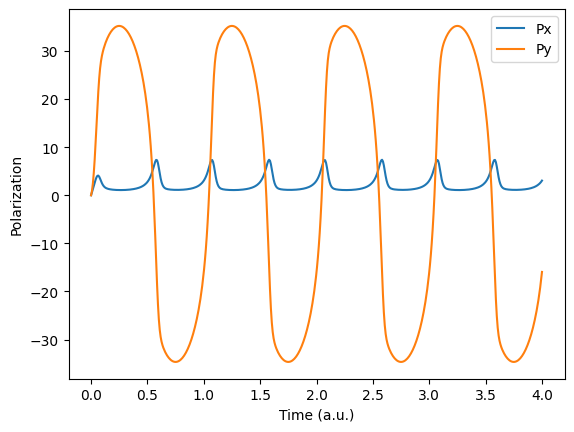

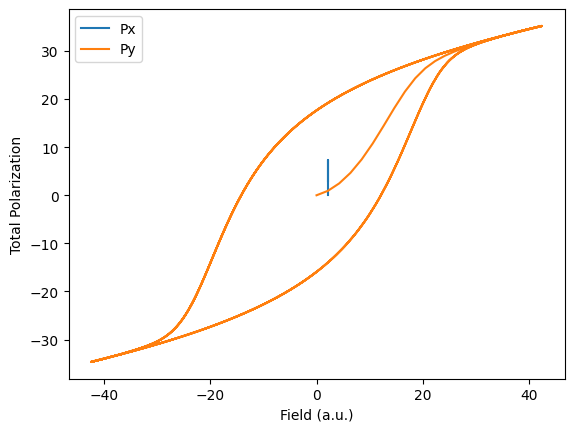

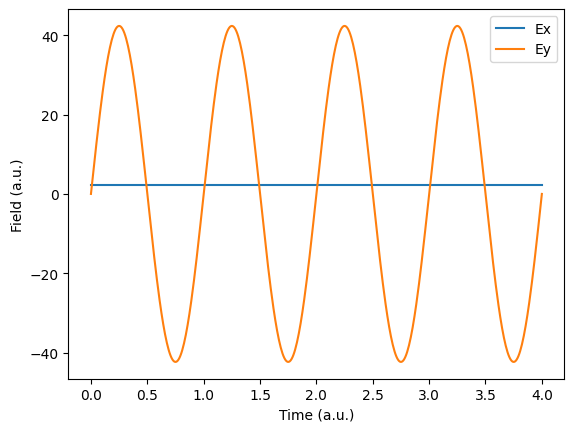

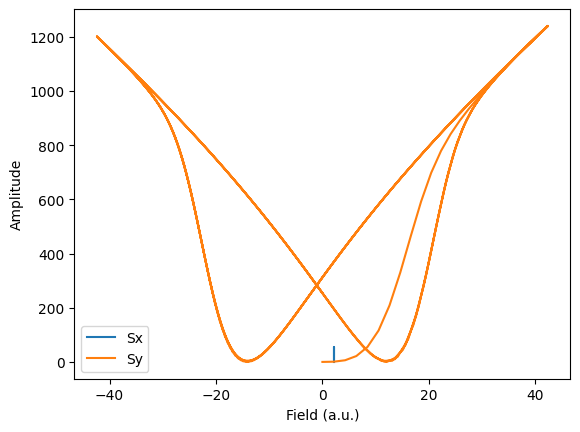

In [ ]:
chromosome = history['populations'][9,7,:]

defect_list = make_defect_list_from_chromosome(chromosome, n,
                                     base_Efx=0.01, base_Efy=0.01,
                                     defect_loc=15.5, defect_scale=0.1)

sim = Ferro2DSim(n=n,
                 time_vec = time_vec,
                 appliedE=applied_field,
                 defects=defect_list,
                 k=k,
                 dep_alpha = dep_alpha,
                 mode = 'tetragonal')

sim.runSim()
sim.plot_summary()

---Performing simulation---


100%|██████████| 498/498 [00:01<00:00, 486.69it/s]


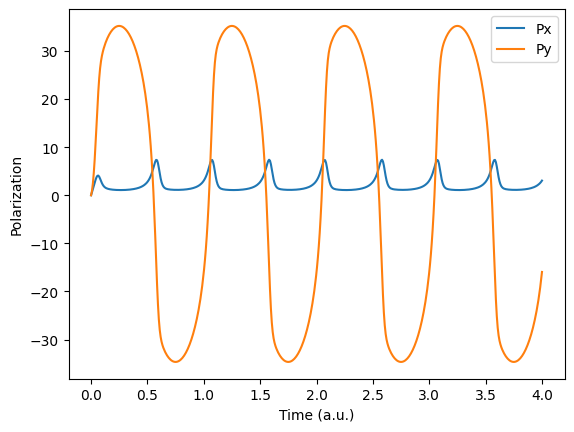

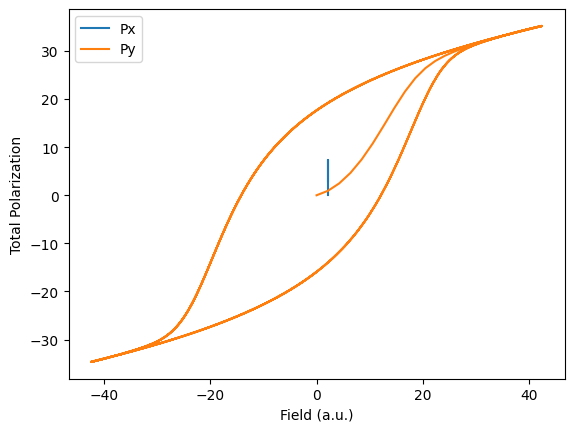

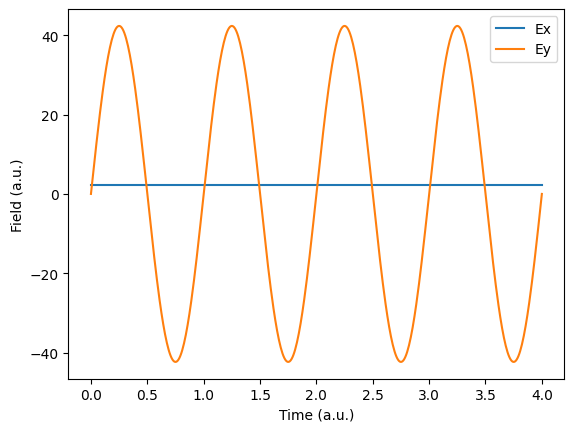

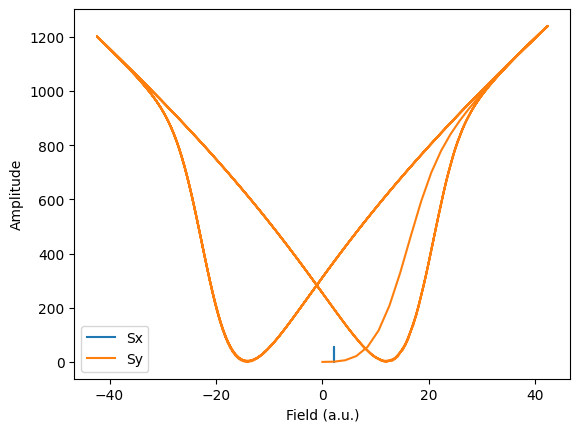

In [ ]:
chromosome = history['populations'][0,7,:]

defect_list = make_defect_list_from_chromosome(chromosome, n,
                                     base_Efx=0.01, base_Efy=0.01,
                                     defect_loc=15.5, defect_scale=0.1)

sim = Ferro2DSim(n=n,
                 time_vec = time_vec,
                 appliedE=applied_field,
                 defects=defect_list,
                 k=k,
                 dep_alpha = dep_alpha,
                 mode = 'tetragonal')

sim.runSim()
sim.plot_summary()

Possible ways to continue:
- identify "features" in defect vectors
- compare average loops at each GA step
- change themutation/cross-over rules